<a href="https://colab.research.google.com/github/MUSSAFARA-RIAZ/ds-learning-log/blob/main/DL_Assignment1_Q2_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Assignment 1 – Question 2

Six classifiers (LR, LR-L2, LR-L1, FNN, FNN-L2, FNN-L1) on five UCI datasets, 100 × hold-out with a 70/30 split.

## Importing Libraries

In [1]:
!pip -q install ucimlrepo

import os, glob, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import sklearn
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Settings

In [2]:
N_RUNS      = 100
TEST_SIZE   = 0.30
HIDDEN      = (64, 32)      # two hidden layers + output layer
EPOCHS      = 30
BATCH_SIZE  = 128
LAMBDA      = 1e-3          # L1 / L2 strength for the FNN
MAX_MISSING = 0.50          # drop a column if more than half of it is missing
SUBSAMPLE   = {"APS": 12000, "HAR": 3000}   # rows kept for the two large datasets (stratified)
FPR_GRID    = np.linspace(0, 1, 101)

MODELS = ["LR", "LR-L2", "LR-L1", "FNN", "FNN-L2", "FNN-L1"]
tables = {}

## Loading and Cleaning Functions

In [3]:
def download_uci_zip(uci_id, slug):
    folder = f"data/{uci_id}"
    path = f"{folder}/data.zip"
    os.makedirs(folder, exist_ok=True)
    if not os.path.exists(path):
        req = urllib.request.Request(f"https://archive.ics.uci.edu/static/public/{uci_id}/{slug}.zip",
                                     headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as r, open(path, "wb") as f:
            f.write(r.read())
    with zipfile.ZipFile(path) as z:
        z.extractall(folder)
    for inner in glob.glob(f"{folder}/**/*.zip", recursive=True):
        if inner != path:
            with zipfile.ZipFile(inner) as z:
                z.extractall(os.path.dirname(inner))
    return folder


def load_uci(uci_id, slug=None, parser=None):
    try:
        raw = fetch_ucirepo(id=uci_id)
        X, y = raw.data.features.copy(), raw.data.targets.iloc[:, 0].copy()
    except Exception:
        X, y = parser(download_uci_zip(uci_id, slug))     # dataset not importable through the API
    X.columns = [str(c).strip() for c in X.columns]
    if y.dtype == object:
        y = y.astype(str).str.strip()
    return X, y


def clean(X, y):
    X = X.apply(pd.to_numeric, errors="coerce")
    df = pd.concat([X, y.rename("__target__")], axis=1).drop_duplicates().reset_index(drop=True)
    X, y = df.drop(columns="__target__"), df["__target__"]
    X = X.loc[:, X.nunique(dropna=True) > 1]            # drop constant columns
    return X, y


def encode_target(y, positive=None):
    if positive is None:
        return LabelEncoder().fit_transform(y.astype(str))
    return (y.astype(str) == str(positive)).astype(int).values


def stratified_subsample(X, y, n, seed=0):
    if n is None or n >= len(X):
        return X, y
    keep, _ = train_test_split(np.arange(len(X)), train_size=n, stratify=y, random_state=seed)
    keep = np.sort(keep)
    return X.iloc[keep].reset_index(drop=True), y.iloc[keep].reset_index(drop=True)

## Exploring the Data

In [4]:
def explore(X, y, name):
    print(f"{name}: {X.shape[0]} rows, {X.shape[1]} columns, "
          f"{int(X.isna().sum().sum())} missing values, "
          f"{int(pd.concat([X, y], axis=1).duplicated().sum())} duplicate rows")
    display(X.head())

    y.value_counts().plot.bar(rot=0, figsize=(5, 3), title="class distribution")
    plt.show()

    X.iloc[:, :6].hist(bins=30, figsize=(11, 4), layout=(2, 3))
    plt.suptitle("first six features")
    plt.tight_layout()
    plt.show()

## Models and Evaluation Functions

In [5]:
def make_lr(name, seed):
    major, minor = (int(v) for v in sklearn.__version__.split(".")[:2])
    if (major, minor) >= (1, 8):
        kw = {"LR": dict(C=np.inf), "LR-L2": dict(l1_ratio=0.0), "LR-L1": dict(l1_ratio=1.0)}[name]
    else:
        kw = {"LR": dict(penalty=None), "LR-L2": dict(penalty="l2"), "LR-L1": dict(penalty="l1")}[name]
    return LogisticRegression(solver="saga", random_state=seed, **kw)


def fit_predict_fnn(name, X_tr, y_tr, X_te, n_classes, seed):
    torch.manual_seed(seed)
    net = nn.Sequential(
        nn.Linear(X_tr.shape[1], HIDDEN[0]), nn.ReLU(),
        nn.Linear(HIDDEN[0], HIDDEN[1]), nn.ReLU(),
        nn.Linear(HIDDEN[1], n_classes),
    ).to(device)
    weights = [p for n, p in net.named_parameters() if n.endswith("weight")]
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters())

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.long, device=device)
    for _ in range(EPOCHS):
        perm = torch.randperm(len(Xt), device=device)
        for i in range(0, len(Xt), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            loss = loss_fn(net(Xt[idx]), yt[idx])
            if name == "FNN-L2":
                loss = loss + LAMBDA * sum((w ** 2).sum() for w in weights)
            elif name == "FNN-L1":
                loss = loss + LAMBDA * sum(w.abs().sum() for w in weights)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    net.eval()
    with torch.no_grad():
        return torch.softmax(net(torch.tensor(X_te, dtype=torch.float32, device=device)), dim=1).cpu().numpy()


def fit_predict(name, X_tr, y_tr, X_te, n_classes, seed):
    if name.startswith("LR"):
        return make_lr(name, seed).fit(X_tr, y_tr).predict_proba(X_te)
    return fit_predict_fnn(name, X_tr, y_tr, X_te, n_classes, seed)


def evaluate(y_te, proba, n_classes):
    pred = proba.argmax(axis=1)
    acc = accuracy_score(y_te, pred)
    if n_classes == 2:
        f1 = f1_score(y_te, pred)
        auc = roc_auc_score(y_te, proba[:, 1])
        fpr, tpr, _ = roc_curve(y_te, proba[:, 1])
        tpr_grid = np.interp(FPR_GRID, fpr, tpr)
    else:
        f1 = f1_score(y_te, pred, average="macro")
        auc = roc_auc_score(y_te, proba, multi_class="ovr", average="macro")
        curves = []
        for c in range(n_classes):
            fpr, tpr, _ = roc_curve((y_te == c).astype(int), proba[:, c])
            curves.append(np.interp(FPR_GRID, fpr, tpr))
        tpr_grid = np.mean(curves, axis=0)
    tpr_grid[0] = 0.0
    return acc, f1, auc, tpr_grid


def split_and_scale(X, y, run):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=run)
    pre = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]).fit(X_tr)
    return pre.transform(X_tr), pre.transform(X_te), y_tr, y_te

## Hold-out Experiment

In [6]:
def run_holdout(X, y, n_classes):
    results = {m: {"acc": [], "f1": [], "auc": [], "roc": []} for m in MODELS}
    for run in range(N_RUNS):
        X_tr, X_te, y_tr, y_te = split_and_scale(X, y, run)      # same split for all six models
        for m in MODELS:
            acc, f1, auc, tpr = evaluate(y_te, fit_predict(m, X_tr, y_tr, X_te, n_classes, seed=run), n_classes)
            results[m]["acc"].append(acc)
            results[m]["f1"].append(f1)
            results[m]["auc"].append(auc)
            results[m]["roc"].append(tpr)
    return results


def report(results, name):
    table = pd.DataFrame({
        "Mean Accuracy": [np.mean(results[m]["acc"]) for m in MODELS],
        "Mean F1":       [np.mean(results[m]["f1"]) for m in MODELS],
        "Mean AUC":      [np.mean(results[m]["auc"]) for m in MODELS],
    }, index=MODELS).round(4)
    display(table)

    plt.figure(figsize=(6, 5))
    for m in MODELS:
        plt.plot(FPR_GRID, np.mean(results[m]["roc"], axis=0), label=f"{m} (AUC = {np.mean(results[m]['auc']):.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=0.8)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"{name}: mean ROC curve over {N_RUNS} runs")
    plt.legend(loc="lower right")
    plt.show()
    return table

## Dataset 1 – APS Failure at Scania Trucks

Dataset 1 – APS: 76000 rows, 170 columns, 1078695 missing values, 0 duplicate rows


,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,60,0.0,20.0,12.0,0.0,0.0,0.0,0.0,0.0,2682.0,...,1098.0,138.0,412.0,654.0,78.0,88.0,0.0,0.0,0.0,0.0
1,82,0.0,68.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1068.0,276.0,1620.0,116.0,86.0,462.0,0.0,0.0,0.0,0.0
2,66002,2.0,212.0,112.0,0.0,0.0,0.0,0.0,0.0,199486.0,...,495076.0,380368.0,440134.0,269556.0,1315022.0,153680.0,516.0,0.0,0.0,0.0
3,59816,NaN,1010.0,936.0,0.0,0.0,0.0,0.0,0.0,0.0,...,540820.0,243270.0,483302.0,485332.0,431376.0,210074.0,281662.0,3232.0,0.0,0.0
4,1814,NaN,156.0,140.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7646.0,4144.0,18466.0,49782.0,3176.0,482.0,76.0,0.0,0.0,0.0


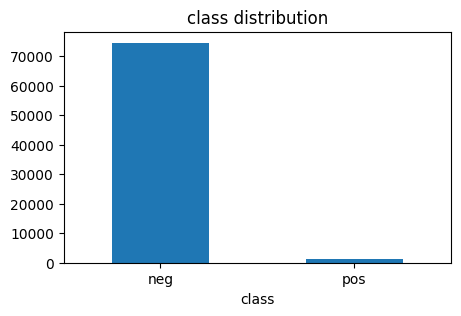

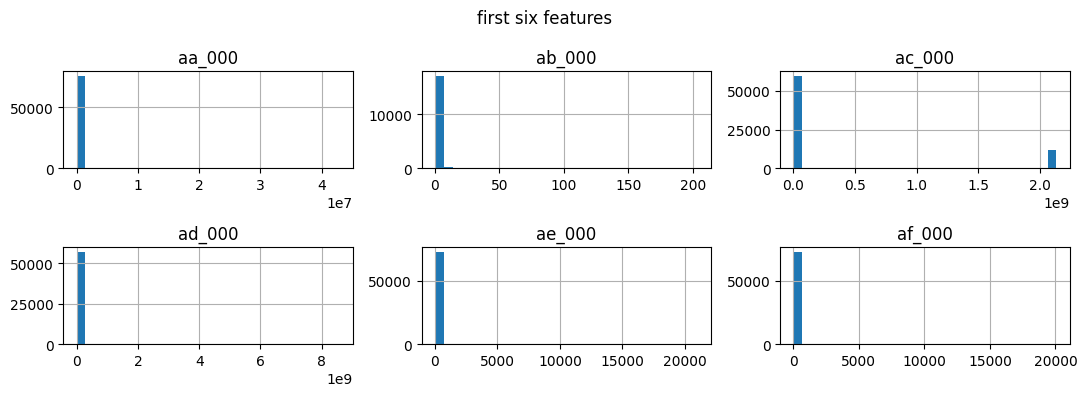

In [7]:
def parse_aps(folder):
    frames = []
    for f in sorted(glob.glob(f"{folder}/**/aps_failure_*_set.csv", recursive=True)):
        with open(f, encoding="utf-8", errors="ignore") as fh:
            header = next(i for i, line in enumerate(fh) if line.lower().startswith("class,"))
        frames.append(pd.read_csv(f, skiprows=header, na_values="na"))
    df = pd.concat(frames, ignore_index=True)          # training + test files combined
    return df.drop(columns=["class"]), df["class"]

X, y = load_uci(421, "aps+failure+at+scania+trucks", parse_aps)
X = X.apply(pd.to_numeric, errors="coerce")
explore(X, y, "Dataset 1 – APS")

In [8]:
X = X.loc[:, X.isna().mean() <= MAX_MISSING]
X, y = stratified_subsample(X, y, SUBSAMPLE["APS"])
X, y = clean(X, y)
y = encode_target(y, positive="pos")
X = X.values
X.shape, np.bincount(y)

((12000, 161), array([11783,   217]))

,Mean Accuracy,Mean F1,Mean AUC
LR,0.9889,0.6599,0.9631
LR-L2,0.9889,0.6600,0.9632
LR-L1,0.9888,0.6573,0.9647
FNN,0.9890,0.6727,0.8872
FNN-L2,0.9893,0.6826,0.9304
FNN-L1,0.9891,0.6707,0.9710


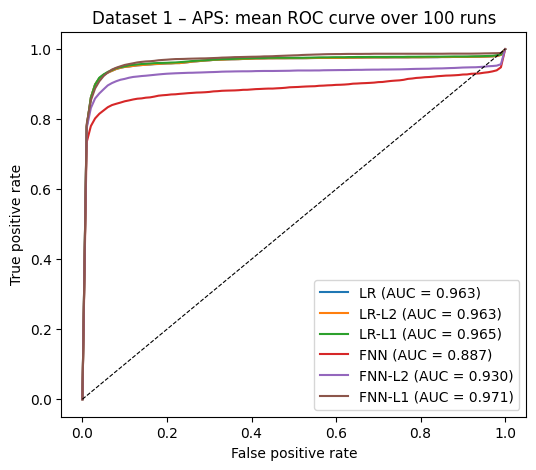

In [9]:
results = run_holdout(X, y, n_classes=2)
tables["Dataset 1 – APS"] = report(results, "Dataset 1 – APS")

## Dataset 2 – Taiwanese Bankruptcy Prediction

Dataset 2 – Bankruptcy: 6819 rows, 95 columns, 0 missing values, 0 duplicate rows


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


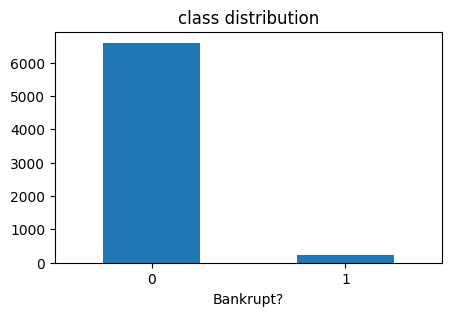

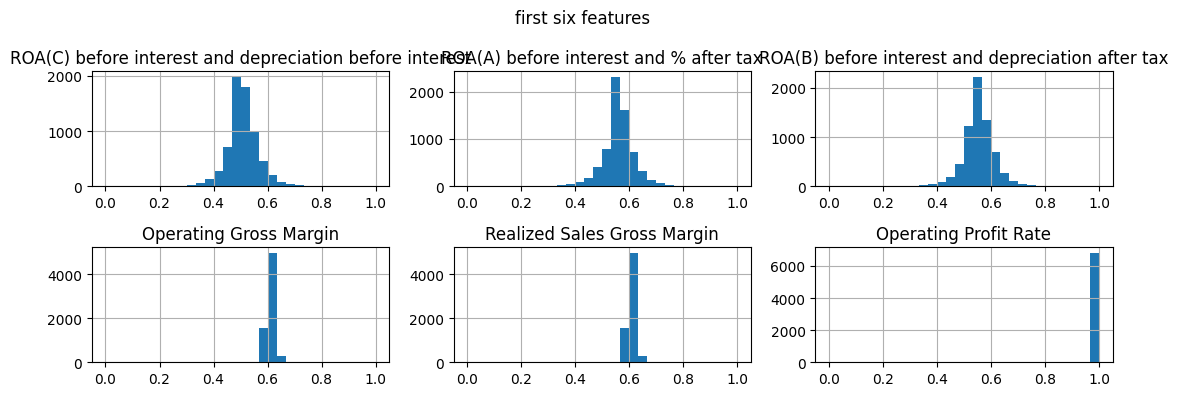

In [10]:
def parse_bankruptcy(folder):
    df = pd.read_csv(glob.glob(f"{folder}/**/*.csv", recursive=True)[0])
    df.columns = df.columns.str.strip()
    return df.drop(columns=["Bankrupt?"]), df["Bankrupt?"]

X, y = load_uci(572, "taiwanese+bankruptcy+prediction", parse_bankruptcy)
explore(X, y, "Dataset 2 – Bankruptcy")

In [11]:
X, y = clean(X, y)
y = encode_target(y, positive=1)
X = X.values
X.shape, np.bincount(y)

((6819, 94), array([6599,  220]))

,Mean Accuracy,Mean F1,Mean AUC
LR,0.9675,0.1783,0.9134
LR-L2,0.9675,0.1782,0.9134
LR-L1,0.9676,0.1778,0.9160
FNN,0.9652,0.3359,0.8660
FNN-L2,0.9674,0.3272,0.8903
FNN-L1,0.9677,0.0908,0.9153


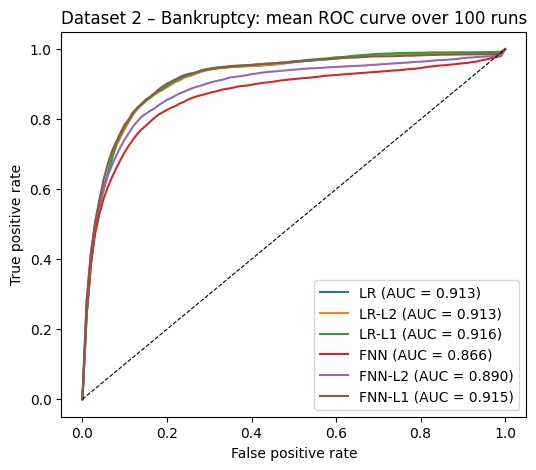

In [12]:
results = run_holdout(X, y, n_classes=2)
tables["Dataset 2 – Bankruptcy"] = report(results, "Dataset 2 – Bankruptcy")

## Dataset 3 – Human Activity Recognition Using Smartphones

Dataset 3 – HAR: 10299 rows, 561 columns, 0 missing values, 0 duplicate rows


,1_tBodyAcc-mean()-X,2_tBodyAcc-mean()-Y,3_tBodyAcc-mean()-Z,4_tBodyAcc-std()-X,5_tBodyAcc-std()-Y,6_tBodyAcc-std()-Z,7_tBodyAcc-mad()-X,8_tBodyAcc-mad()-Y,9_tBodyAcc-mad()-Z,10_tBodyAcc-max()-X,...,552_fBodyBodyGyroJerkMag-meanFreq(),553_fBodyBodyGyroJerkMag-skewness(),554_fBodyBodyGyroJerkMag-kurtosis(),"555_angle(tBodyAccMean,gravity)","556_angle(tBodyAccJerkMean),gravityMean)","557_angle(tBodyGyroMean,gravityMean)","558_angle(tBodyGyroJerkMean,gravityMean)","559_angle(X,gravityMean)","560_angle(Y,gravityMean)","561_angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


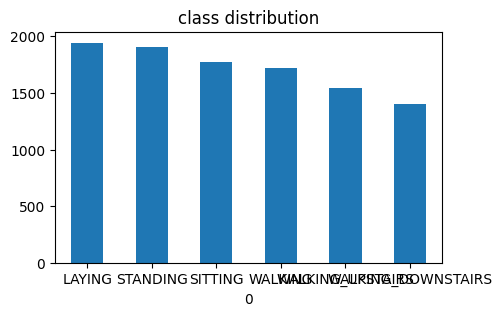

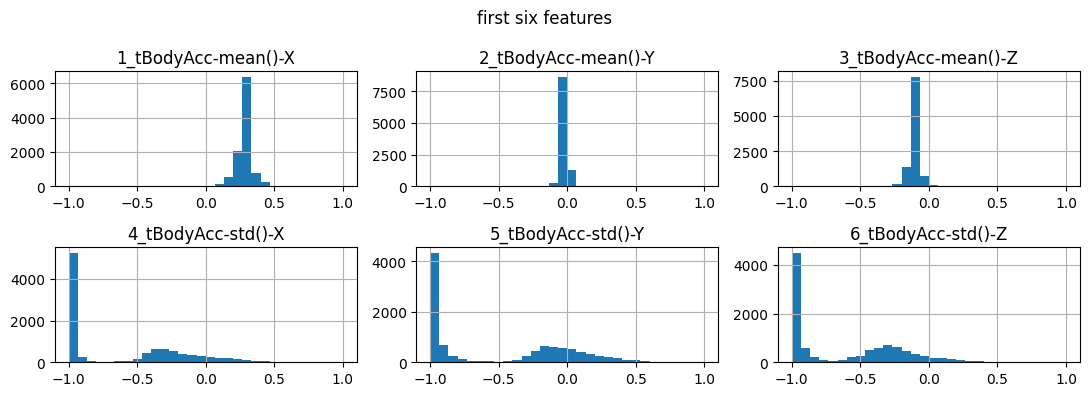

In [13]:
def parse_har(folder):
    find = lambda name: glob.glob(f"{folder}/**/{name}", recursive=True)[0]
    feats = pd.read_csv(find("features.txt"), sep=r"\s+", header=None)[1].tolist()
    names = [f"{i + 1}_{n}" for i, n in enumerate(feats)]
    acts = pd.read_csv(find("activity_labels.txt"), sep=r"\s+", header=None, index_col=0)[1].to_dict()
    X = pd.concat([pd.read_csv(find(f"X_{s}.txt"), sep=r"\s+", header=None, names=names) for s in ["train", "test"]],
                  ignore_index=True)                   # training + test files combined
    y = pd.concat([pd.read_csv(find(f"y_{s}.txt"), header=None)[0] for s in ["train", "test"]],
                  ignore_index=True).map(acts)
    return X, y

X, y = load_uci(240, "human+activity+recognition+using+smartphones", parse_har)
X = X.drop(columns=[c for c in X.columns if "subject" in c.lower()])
explore(X, y, "Dataset 3 – HAR")

In [14]:
X, y = stratified_subsample(X, y, SUBSAMPLE["HAR"])
X, y = clean(X, y)
y = encode_target(y)
X = X.values
X.shape, np.bincount(y)

((3000, 561), array([566, 518, 555, 502, 409, 450]))

,Mean Accuracy,Mean F1,Mean AUC
LR,0.9555,0.9566,0.9975
LR-L2,0.9555,0.9566,0.9975
LR-L1,0.9554,0.9565,0.9975
FNN,0.9583,0.9596,0.9975
FNN-L2,0.9588,0.9601,0.9976
FNN-L1,0.9593,0.9604,0.9979


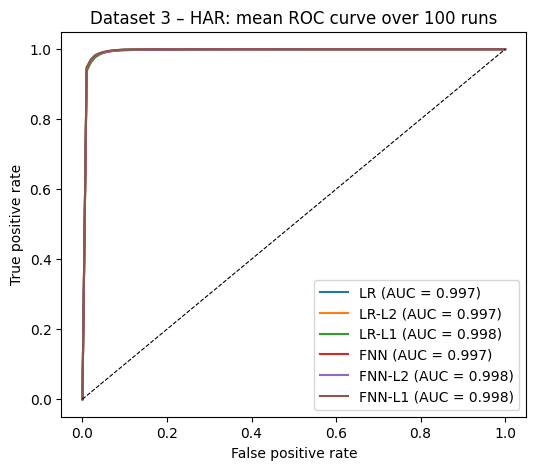

In [15]:
results = run_holdout(X, y, n_classes=6)
tables["Dataset 3 – HAR"] = report(results, "Dataset 3 – HAR")

## Dataset 4 – Ionosphere

Dataset 4 – Ionosphere: 351 rows, 34 columns, 0 missing values, 1 duplicate rows


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute25,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,0.56811,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.20332,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,0.57528,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,1.00000,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,0.03286,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697


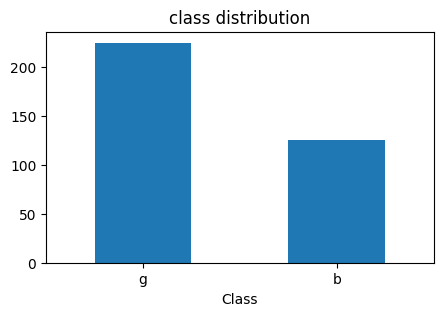

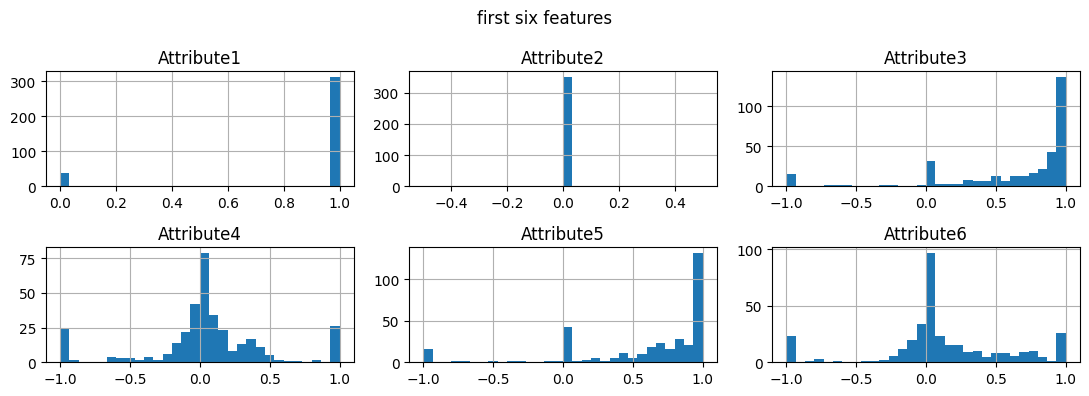

In [16]:
def parse_ionosphere(folder):
    df = pd.read_csv(glob.glob(f"{folder}/**/ionosphere.data", recursive=True)[0], header=None)
    return df.iloc[:, :-1], df.iloc[:, -1]

X, y = load_uci(52, "ionosphere", parse_ionosphere)
explore(X, y, "Dataset 4 – Ionosphere")

In [17]:
X, y = clean(X, y)
y = encode_target(y, positive="b")
X = X.values
X.shape, np.bincount(y)

((350, 33), array([225, 125]))

,Mean Accuracy,Mean F1,Mean AUC
LR,0.8762,0.8068,0.8770
LR-L2,0.8750,0.8030,0.8970
LR-L1,0.8770,0.8069,0.9013
FNN,0.8874,0.8329,0.9520
FNN-L2,0.8867,0.8313,0.9512
FNN-L1,0.8817,0.8216,0.9431


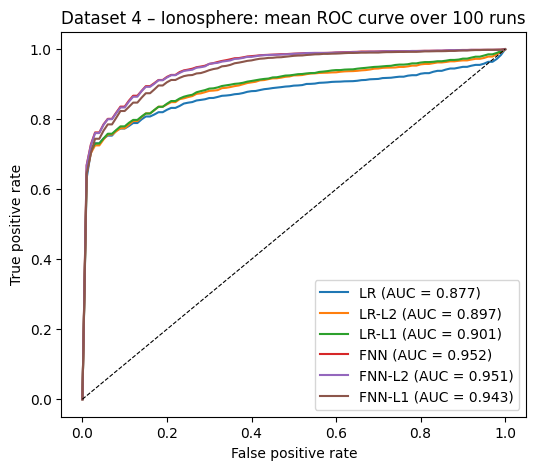

In [18]:
results = run_holdout(X, y, n_classes=2)
tables["Dataset 4 – Ionosphere"] = report(results, "Dataset 4 – Ionosphere")

## Dataset 5 – Predict Students' Dropout and Academic Success

Dataset 5 – Students: 4424 rows, 36 columns, 0 missing values, 0 duplicate rows


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


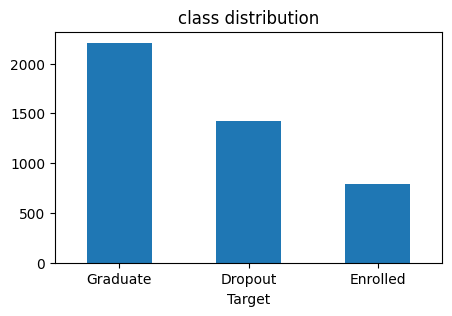

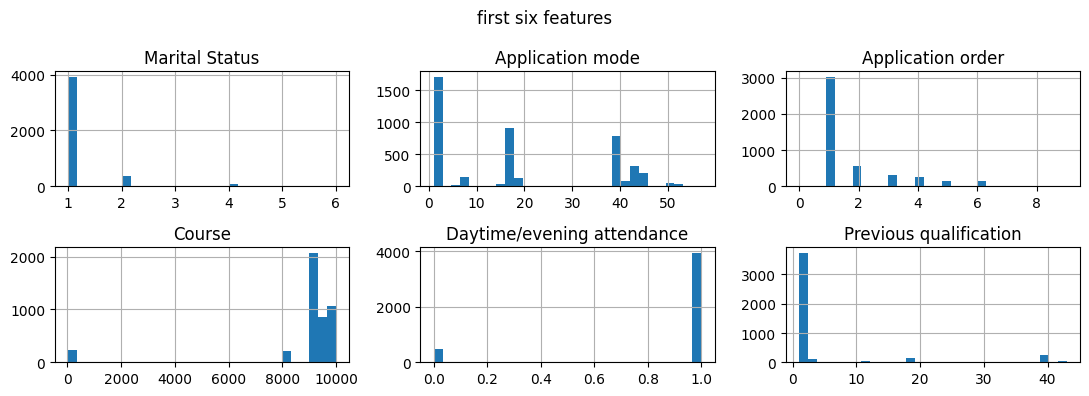

In [19]:
def parse_students(folder):
    df = pd.read_csv(glob.glob(f"{folder}/**/*.csv", recursive=True)[0], sep=";")
    df.columns = df.columns.str.strip()
    return df.drop(columns=["Target"]), df["Target"]

X, y = load_uci(697, "predict+students+dropout+and+academic+success", parse_students)
explore(X, y, "Dataset 5 – Students")

In [20]:
nominal = ["marital status", "application mode", "course", "previous qualification", "nacionality",
           "mother's qualification", "father's qualification", "mother's occupation", "father's occupation"]
X = pd.get_dummies(X, columns=[c for c in X.columns if c.lower() in nominal], dtype=float)
X, y = clean(X, y)
y = encode_target(y)
X = X.values
X.shape, np.bincount(y)

((4424, 247), array([1421,  794, 2209]))

,Mean Accuracy,Mean F1,Mean AUC
LR,0.7632,0.6871,0.8717
LR-L2,0.7633,0.6872,0.8718
LR-L1,0.7659,0.6891,0.8755
FNN,0.7273,0.6608,0.8362
FNN-L2,0.7388,0.6712,0.8514
FNN-L1,0.7692,0.6993,0.8811


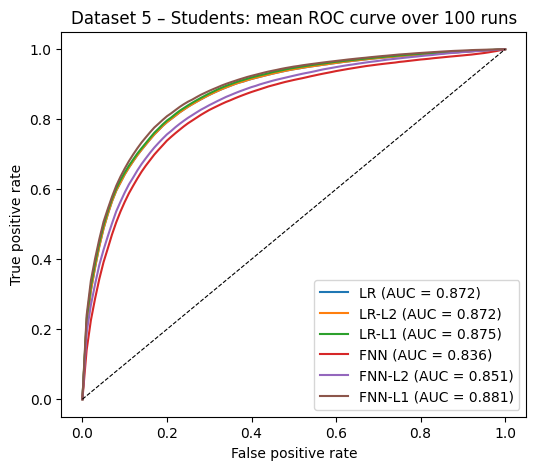

In [21]:
results = run_holdout(X, y, n_classes=3)
tables["Dataset 5 – Students"] = report(results, "Dataset 5 – Students")

## Results for All Datasets

In [22]:
pd.concat(tables)

Mean Accuracy  Mean F1  Mean AUC
Dataset 1 – APS        LR             0.9889   0.6599    0.9631
                       LR-L2          0.9889   0.6600    0.9632
                       LR-L1          0.9888   0.6573    0.9647
                       FNN            0.9890   0.6727    0.8872
                       FNN-L2         0.9893   0.6826    0.9304
                       FNN-L1         0.9891   0.6707    0.9710
Dataset 2 – Bankruptcy LR             0.9675   0.1783    0.9134
                       LR-L2          0.9675   0.1782    0.9134
                       LR-L1          0.9676   0.1778    0.9160
                       FNN            0.9652   0.3359    0.8660
                       FNN-L2         0.9674   0.3272    0.8903
                       FNN-L1         0.9677   0.0908    0.9153
Dataset 3 – HAR        LR             0.9555   0.9566    0.9975
                       LR-L2          0.9555   0.9566    0.9975
                       LR-L1          0.9554   0.9565    0.9975
                       FNN            0.9583   0.9596    0.9975
                       FNN-L2         0.9588   0.9601    0.9976
                       FNN-L1         0.9593   0.9604    0.9979
Dataset 4 – Ionosphere LR             0.8762   0.8068    0.8770
                       LR-L2          0.8750   0.8030    0.8970
                       LR-L1          0.8770   0.8069    0.9013
                       FNN            0.8874   0.8329    0.9520
                       FNN-L2         0.8867   0.8313    0.9512
                       FNN-L1         0.8817   0.8216    0.9431
Dataset 5 – Students   LR             0.7632   0.6871    0.8717
                       LR-L2          0.7633   0.6872    0.8718
                       LR-L1          0.7659   0.6891    0.8755
                       FNN            0.7273   0.6608    0.8362
                       FNN-L2         0.7388   0.6712    0.8514
                       FNN-L1         0.7692   0.6993    0.8811